# LLM

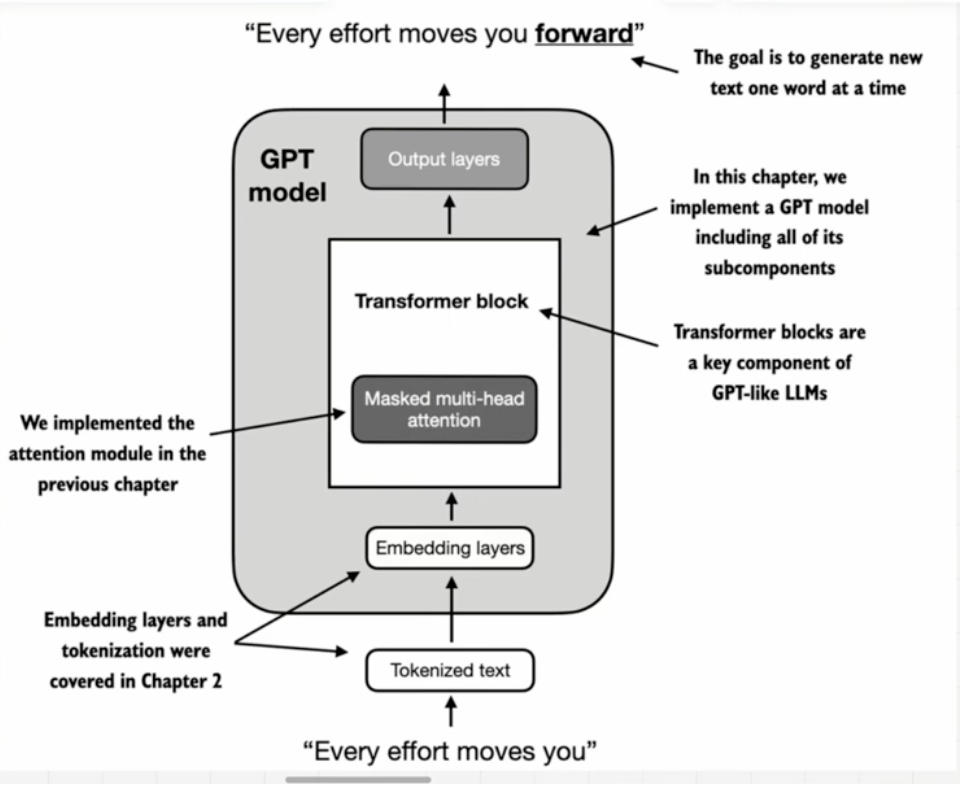

## Transformer

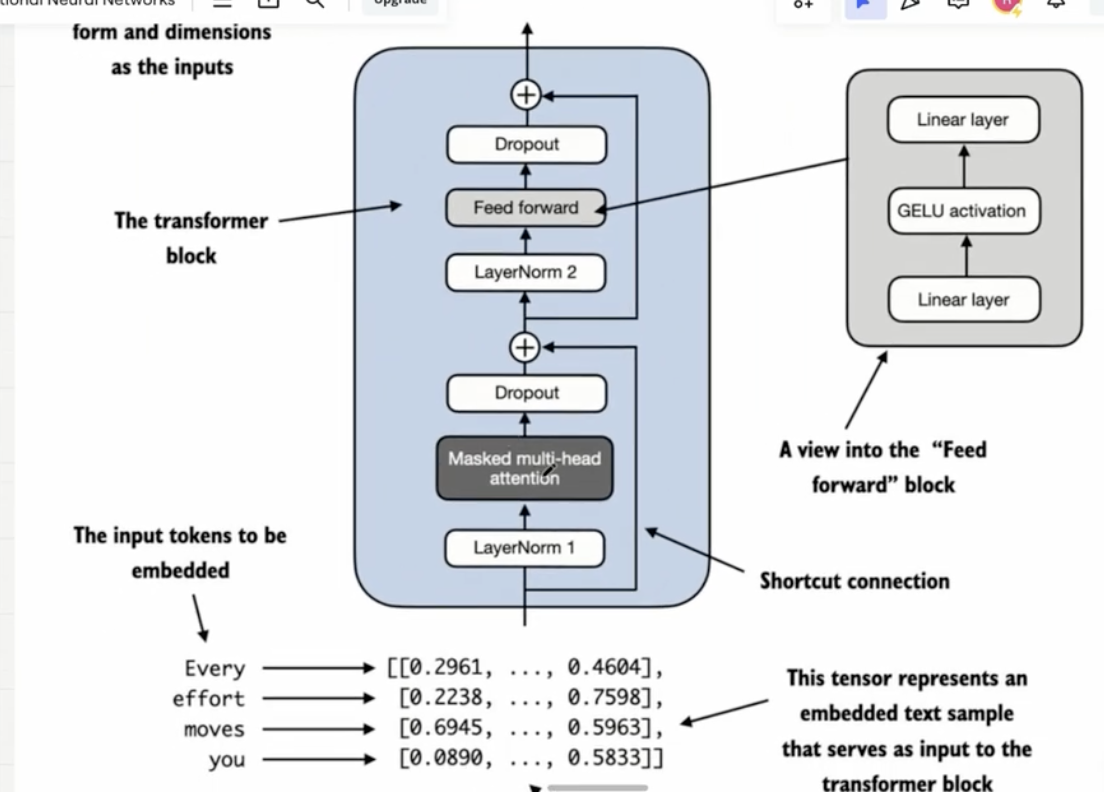

1. outputs have the same form and dimension as the inputs from the transformer

## GPT2 Config

In [6]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

Using the above configuration, we will build a GPT placeholder architecture

## Dummy GPT Model Class

In [16]:
import torch
import torch.nn as nn

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

class DummyGPT2Model(nn.Module):
    
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(
            cfg["vocab_size"],cfg["emb_dim"]
        )

        self.pos_emb = nn.Embedding(
            cfg["context_length"],cfg["emb_dim"]
        )

        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"],cfg["vocab_size"],bias = False
        )


    def forward(self, input_token_indices):
        batch_size, seq_len = input_token_indices.shape

        ## Convert token indices to embeddings
        token_embeddings = self.tok_emb(input_token_indices)

        ## Positional embeddings
        ## torch.arange(4) gives [0,1,2,3] indices
        ## those indices embeddings are fetched from positional embeddings
        positional_embeddings = self.pos_emb(torch.arange(seq_len, device = input_token_indices.device))
        
        
        x = token_embeddings + positional_embeddings

        ## drop out
        ## for generalization and reducing overfitting
        x = self.drop_emb(x)

        ## Transformer blocks
        x = self.trf_blocks(x)

        ## Layer Normalization
        x = self.final_norm(x)

        ## getting logits out of the model
        ## siz eof this is num_tokens * vocab_size
        logits = self.out_head(x)

        return logits



## Output Format Explanation

Consider example sentence "Every effort moves you"

1. Suppose if each word is atoken then there are 4 tokens

2. output we get is a 

Token1  ------------------- (vocab_size)

Token2  ------------------- (vocab_size)

Token3  ------------------- (vocab_size)

Token4  ------------------- (vocab_size)

That is num_tokens * vocab_size

3. Here 4 next word predictions are happening - 

```
Every - 
Every effort - 
Every effort moves - 
Every effort moves you - 
```

4. for each prediction task, we get a probability distribution for the next word among vocab_size

### STEP 1: TOKENIZATION

In [17]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


### STEP 2: CREATE AN INSTANCE OF DUMMYGPTMODEL

In [18]:
torch.manual_seed(123)
model = DummyGPT2Model(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)
